In [1]:
import LeafletSC
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.3.0+cu121
12.1
2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [3]:
# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *
from LeafletSC.utils.helpers import * 
from LeafletSC.utils.visualization import *

In [4]:
# published metadata
metacells = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/human_MTG_2018-06-14_samples-columns.csv"
# read in metacells 
cells_pub = pd.read_csv(metacells)
cells_pub.head()

,sample_name,sample_id,sample_type,organism,donor,sex,age_days,brain_hemisphere,brain_region,brain_subregion,...,percent_mt_exon_reads,percent_reads_unique,percent_synth_reads,percent_ecoli_reads,percent_aligned_reads_total,complexity_cg,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,class,cluster
0,F1S4_160106_001_B01,556012415,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.090052,85.573696,0.007535,0.018537,92.418885,0.316637,8635,5253,GABAergic,Inh L4-6 SST B3GAT2
1,F1S4_160106_001_C01,556012410,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.052470,87.619777,0.002790,0.007265,94.001319,0.287989,11697,8246,Glutamatergic,Exc L5-6 RORB TTC12
2,F1S4_160106_001_E01,556012412,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.042946,86.448562,0.004573,0.006413,92.871217,0.280933,12138,8467,Glutamatergic,Exc L5-6 FEZF2 ABO
3,F1S4_160106_001_G01,556012414,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055851,84.497105,0.006585,0.008131,90.198132,0.293406,12191,8287,Glutamatergic,Exc L5-6 FEZF2 EFTUD1P1
4,F1S4_160106_001_H01,556012409,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055692,87.014752,0.005061,0.011116,93.460676,0.293106,10535,6922,Glutamatergic,Exc L3-5 RORB ESR1


In [5]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [6]:
K = 10 

hypers = {
            "eta" : 1/K, # 1 or 1/K
            "alpha_prior" : 1., 
            "pi_prior" : 1. 
        }

In [7]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file='/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet.h5'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# try loading just cell_types of interest 

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  12748
Number of junctions after removing singletons:  12748
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  208
The number of unique junctions in the data is:  12749
The maximum junction count was initially:  5117
0
The maximum junction count is now:  5117
The number of junctions in the data is:  12749
The number of cells in the data is:  208
The number of cell types in the data is:  4
The number of cells going into training data is:
208
208
The number of junctions is:  12749
The number of intron clusters observed is:  4677
The number of genes is:  3297
The number of cells is:  208


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [8]:
init_labels = cell_ids_conversion["cell_type"]
# Set GAMMA to dummy values based on the initial labels
cell_type_dummy = pd.get_dummies(init_labels)
cell_type_dummy_columns = cell_type_dummy.columns
# make dataframe of cell_type_dummy_columns and index from 0 to len(cell_type_dummy_columns)
cell_type_dummy_df = pd.DataFrame(cell_type_dummy_columns, columns=["cell_type"])
cell_type_dummy_df["cell_type_index"] = range(len(cell_type_dummy_columns))
# we will just save this here for now and run CAVI and map everything back after before doing differential splicing analysis 
cell_type_dummy_df

,cell_type,cell_type_index
0,GABAergic,0
1,Glutamatergic,1
2,Non-neuronal,2
3,no class,3


### Run full model

In [9]:
num_trials = 500 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
K = 4
print("The K used is: ", K)
results = [ calculate_CAVI(K, my_data, float_type, hypers, num_iterations = num_iters, init_labels = init_labels, fixed_cell_types = True) 
           for t in range(num_trials) ]

The K used is:  4
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions
Initializing cell state proportions with init_labels
Running CAVI with fixed cell types
z and theta will not be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
ELBO converged @ -8037712.0 CAVI iteration # 2 complete
ELBO converged @ -8037712.0 CAVI iteration # 2 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions
Initializing cell state proportions with init_labels
Running CAVI with fixed cell types
z and theta will not be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
ELBO converged @ -8037712.0 CAVI iteration # 2 complete
ELBO converged @ -8037712.0 CAVI iteration # 2 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions
Initializing cell state proportions with init_labels
Running CAVI with fixed c

In [10]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
elbos_all

The trial with the highest ELBO was 286


array([-37540432. ,  -8037711. ,  -8037712.5,  -8037711. ,  -8037711. ])

In [11]:
# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

In [12]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
alpha_plus_pi = ALPHA_f+PI_f

juncs_probs.shape

torch.Size([12749, 4])

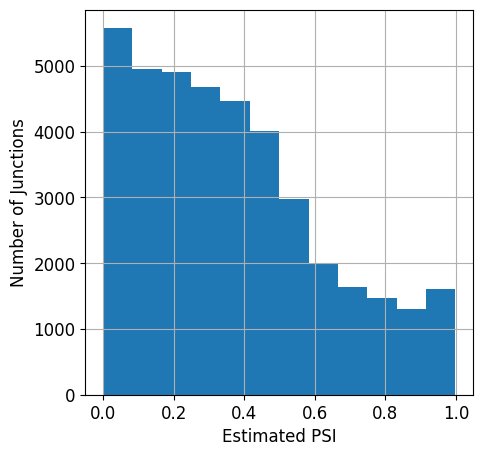

In [13]:
# Create boolean mask from tensor1
mask = alpha_plus_pi >= 10

# Apply the mask to tensor2 to get filtered values
filtered_values = juncs_probs[mask]

plt.figure(figsize=(5, 5))
# Plot the values
plt.hist(filtered_values.numpy(), bins=12)  # Assuming you want a histogram, adjust as needed
plt.xlabel('Estimated PSI', fontsize=12)
# Set y-label with larger font size (if you need it)
plt.ylabel('Number of Junctions', fontsize=12)  
# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# add grid 
plt.grid()

In [14]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values
juncs_probs_df.head()

,0,1,2,3,junction_id_index,junction_id
0,0.617647,0.595238,0.941176,0.762712,0,1_150150287_150150911
1,0.003623,0.026616,0.007752,0.080597,1,1_150151058_150158818
2,0.283276,0.467186,0.500000,0.537143,2,1_69678478_69760190
3,0.415385,0.481818,0.500000,0.325581,3,1_16970767_16971464
4,0.466667,0.312000,0.500000,0.288462,4,1_172551626_172553259


In [15]:
cell_type_dummy_df

,cell_type,cell_type_index
0,GABAergic,0
1,Glutamatergic,1
2,Non-neuronal,2
3,no class,3


In [16]:
scores_all_juncs = []

for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [0, 1]]
    b = PI_f[junc_index, [0, 1] ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values

In [17]:
# Compute the logistic score
scores_all_juncs_df["logistic_score"] = 1 / (1 + np.exp(-scores_all_juncs_df["score"].values))

# Compute the Bayesian q-value for FDR
scores_all_juncs_df["q_value"] = 1 - scores_all_juncs_df["logistic_score"].values 
scores_all_juncs_df["significance"] = np.where(scores_all_juncs_df["q_value"].values < 0.01, "yes", "no")

In [18]:
scores_all_juncs_df["significance"].value_counts()

significance
no     8100
yes    4649
Name: count, dtype: int64

In [19]:
4649/(4649+8100)

0.36465605145501606

In [20]:
# merge scores_all_juncs_df with junction_ids_conversion to get gene_id and junction_id 
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index")
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id
7392,415.507568,7392,1.0,0.0,yes,10_77019099_77027822,3563,ENSG00000156113.25
788,401.745605,788,1.0,0.0,yes,8_103819629_103885297,2933,ENSG00000176406.25
2238,401.745605,2238,1.0,0.0,yes,8_103766537_103885297,2933,ENSG00000176406.25
162,320.983398,162,1.0,0.0,yes,2_71433283_71434741,650,ENSG00000075292.19
2640,306.741699,2640,1.0,0.0,yes,16_5867335_6316994,4877,ENSG00000078328.23
2433,292.519531,2433,1.0,0.0,yes,12_56160320_56161386,3965,ENSG00000092841.19
5025,271.335449,5025,1.0,0.0,yes,20_47347926_47356656,5964,ENSG00000101040.20
7878,182.218628,7878,1.0,0.0,yes,10_18150975_18401923,3444,ENSG00000165995.24
1258,181.446289,1258,1.0,0.0,yes,16_6317057_6654602,4878,ENSG00000078328.23
677,178.062500,677,1.0,0.0,yes,6_135492291_135497582,2419,ENSG00000135541.22


In [21]:
# check if "ENSG00000179915 (NRXN1)" in any gene_id or ENSG00000156642 (NPTN)
nrxn1 = junction_ids_conversion.index[junction_ids_conversion['gene_id'].str.contains('ENSG00000179915')].tolist()

In [22]:
nrxn1_juncs=junction_ids_conversion["junction_id_index"][nrxn1]

In [23]:
scores_all_juncs_df[scores_all_juncs_df["junction_id_index"].isin(nrxn1_juncs)].sort_values("score", ascending=False)

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id
5636,48.055786,5636,1.000000,0.000000e+00,yes,2_50053590_50091322,1098,ENSG00000179915.25
5114,16.189362,5114,1.000000,9.312141e-08,yes,2_50055044_50091322,1098,ENSG00000179915.25
6456,12.153503,6456,0.999995,5.269850e-06,yes,2_50925955_51027501,1101,ENSG00000179915.25
8713,12.153503,8713,0.999995,5.269850e-06,yes,2_50925952_51027501,1101,ENSG00000179915.25
5113,10.619110,5113,0.999976,2.444379e-05,yes,2_50053590_50054954,1098,ENSG00000179915.25
8038,7.565323,8038,0.999482,5.178418e-04,yes,2_49922251_49943712,1096,ENSG00000179915.25
5111,7.565323,5111,0.999482,5.178418e-04,yes,2_49922251_49943703,1096,ENSG00000179915.25
7563,3.842560,7563,0.979011,2.098868e-02,no,2_50236970_50346690,1099,ENSG00000179915.25
6455,3.842560,6455,0.979011,2.098868e-02,no,2_50236970_50465441,1099,ENSG00000179915.25
5112,0.359802,5112,0.588993,4.110074e-01,no,2_49943791_50053270,1097,ENSG00000179915.25


In [24]:
cell_type1_index=0
cell_type2_index=1
cell_type1 = cell_type_dummy_df[cell_type_dummy_df["cell_type_index"]==cell_type1_index]["cell_type"].values[0]
cell_type2 = cell_type_dummy_df[cell_type_dummy_df["cell_type_index"]==cell_type2_index]["cell_type"].values[0]
cell_types = [cell_type1, cell_type2]
print(cell_types)

['GABAergic', 'Glutamatergic']


In [66]:
junc = 7878
clust = get_cluster(junc, junction_ids_conversion)
gene = get_gene(junc, junction_ids_conversion)
print(f"The cluster is {clust} and the gene is {gene}")

The cluster is 3444 and the gene is ENSG00000165995.24


In [67]:
simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

In [68]:
# Filter the DataFrame for the specified cell types
filtered_df = simple_data_human[simple_data_human["Cluster"] == clust]

# Only include cell_types of interest
filtered_df = filtered_df[filtered_df["cell_type"].isin(cell_types)]

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


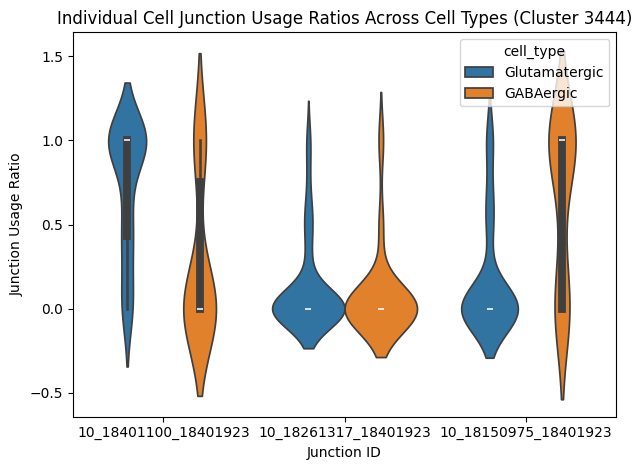

In [69]:
# Create a violin plot for each cell type and junction
sns.violinplot(x='junction_id', y='juncratio', hue='cell_type', data=filtered_df)
plt.title(f'Individual Cell Junction Usage Ratios Across Cell Types (Cluster {clust})')
plt.xlabel('Junction ID')
plt.ylabel('Junction Usage Ratio')

plt.tight_layout()
plt.show()

cell_type
Glutamatergic    34
GABAergic        12
Name: count, dtype: int64


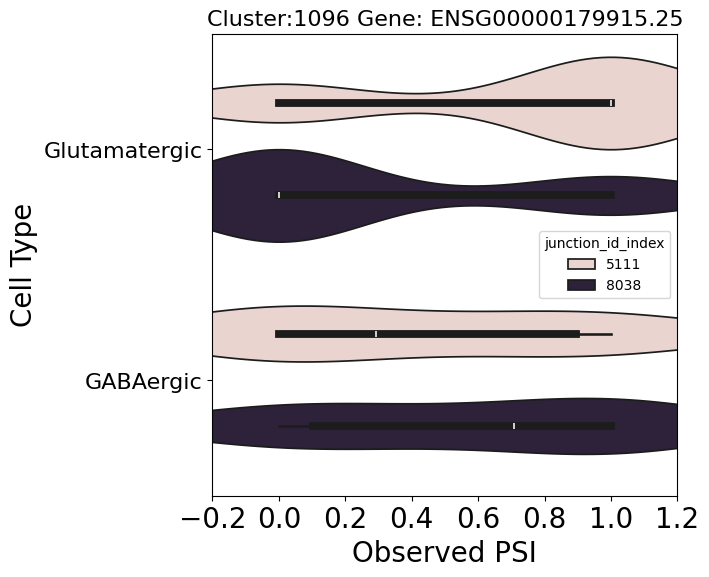

In [65]:
quick_clust_plot(clust, simple_data_human, gene_name=True, cell_types=cell_types)

In [ ]:
# summarize total number of junctions that are significantly differentially spliced between the two
# cell types of interest and also the number of unique genes they belong to

print("The number of junctions that are significantly differentially spliced between the two cell types is: ", scores_all_juncs_df["significance"].value_counts()["yes"])
print("The number of unique genes that these junctions belong to is: ", scores_all_juncs_df[scores_all_juncs_df["significance"]=="yes"]["gene_id"].nunique())

In [ ]:
# print the gene that has the most number of junctions that are significantly differentially spliced between the two cell types
gene_counts = scores_all_juncs_df[scores_all_juncs_df["significance"]=="yes"]["gene_id"].value_counts()

# print the top 5 genes with the most DS junctions
print("The top 5 genes with the most number of junctions that are significantly differentially spliced between the two cell types are: ")
print(gene_counts.head(5))

In [ ]:
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 
print(percentages)

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.005, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [ ]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']

# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)

In [ ]:
# Create the barplot using the cell_type_colors palette
plt.figure(figsize=(6, 6))
sns.barplot(x="cell_type", y="percentage", data=cell_types_summary)
plt.axhline(0.005, ls='--', color='grey')
plt.ylabel("Percentage", fontsize=23)
plt.xlabel("Observed Cell Types", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)

In [ ]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

In [ ]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f

In [ ]:
from scipy.stats import fisher_exact

PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(PHI_f_melt['variable'], PHI_f_melt['cell_type'])
contingency_table

In [ ]:
# plot clustermap of contingency table
g = sns.clustermap(contingency_table.T, cmap="YlGnBu", figsize=(8, 6), annot=True, fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': '% of cells'})
# Increase the font size of the x-axis and y-axis tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=12) # Set x-axis label size
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12) # Set y-axis label size
# remove x lab 
g.ax_heatmap.set_xlabel("")